# Setup

Install dependencies, clone the repo, and import required libraries and modules.

In [1]:
# Install dependencies
!pip -q install transformers sentence-transformers tqdm pandas numpy pillow


In [2]:
# Clone the project repo
!git clone https://github.com/gizayceylan/FakeNews.git

# Add it to Python path
import sys
sys.path.append("/content/FakeNews")


Cloning into 'FakeNews'...
remote: Enumerating objects: 220, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 220 (delta 23), reused 12 (delta 6), pack-reused 171 (from 1)
Receiving objects: 100% (220/220), 19.28 MiB | 21.05 MiB/s, done.
Resolving deltas: 100% (111/111), done.


In [3]:
# Imports
import os, json
import numpy as np
import pandas as pd
import torch

from tqdm import tqdm
from PIL import Image
from google.colab import files

from transformers import CLIPProcessor, CLIPModel
from sentence_transformers import SentenceTransformer, util

# Data

Load the pre-processed and balanced Fakeddit subset.

In [4]:
# Unzip fakeddit_images.zip from /content/FakeNews/assets/content/master_pipeline_assets/
!unzip -q /content/FakeNews/assets/fakeddit_images.zip -d /content/FakeNews/assets

In [5]:
# Load the pre-processed metadata
subset_path = "/content/FakeNews/assets/fakeddit_balanced_subset.csv"
balanced_df = pd.read_csv(subset_path)

# Define the path for the image directory (which was unzipped)
img_dir = "/content/FakeNews/assets/content/fakeddit_images"

# Update the DataFrame paths to reflect the new location
balanced_df['image_path'] = balanced_df['image_path'].apply(
    lambda p: os.path.join(img_dir, os.path.basename(p))
)

print(f"Loaded {len(balanced_df)} clean samples.")
print("Shape subset:", balanced_df.shape)
balanced_df.head()


Loaded 150 clean samples.
Shape subset: (150, 5)


,image_path,clean_title,label,image_url,blip2_caption
0,/content/FakeNews/assets/content/fakeddit_imag...,bernie sander announces his campaign for presi...,0,https://preview.redd.it/m0yhjb563ek21.jpg?widt...,"yoda is sitting in a chair with the caption, ""..."
1,/content/FakeNews/assets/content/fakeddit_imag...,my dom nsfw,0,https://external-preview.redd.it/N5dbbbo3nx7uw...,a woman is standing in front of microphones
2,/content/FakeNews/assets/content/fakeddit_imag...,my inlaws moved into a building that hasnt upd...,1,https://preview.redd.it/knd5hhyozny21.jpg?widt...,a room with purple walls and green furniture
3,/content/FakeNews/assets/content/fakeddit_imag...,a leaf fell perfectly in the wet cement,1,https://preview.redd.it/70y4l9yhcsc31.jpg?widt...,a leaf on the sidewalk
4,/content/FakeNews/assets/content/fakeddit_imag...,a philadelphia bar cut a hall of famers baseba...,1,https://preview.redd.it/0ksailoiupe31.jpg?widt...,a baseball card with a picture of a man on it


In [6]:
# Display the number of fake/real labels
print(balanced_df["label"].value_counts())

label
0    75
1    75
Name: count, dtype: int64


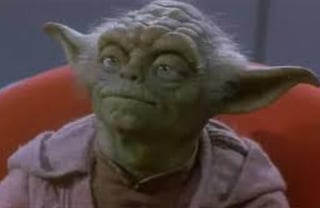

In [7]:
# Test a sample
Image.open(balanced_df["image_path"].iloc[0])


# Models

In [8]:
# Check for GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [9]:
# CLIP
clip_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(clip_name)
clip_processor = CLIPProcessor.from_pretrained(clip_name)
clip_model.to(device)
clip_model.eval()
print("\n-----------------------------------------------------")
print("CLIP loaded successfully.")
print("-----------------------------------------------------")

# SentenceTransformer
sim_model = SentenceTransformer("all-mpnet-base-v2")
sim_model.to(device)
print("\n-----------------------------------------------------")
print("MPNet loaded successfully.")
print("-----------------------------------------------------")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


-----------------------------------------------------
MPNet loaded successfully.
-----------------------------------------------------


# Similarity

In [10]:
def context_alignment(user_text: str, AI_caption: str, image_path: str) -> dict:
    """
    Computes two-way alignment scores:
    1. Semantic: Text vs Caption
    2. Cross-modal: Image vs Text (User Claim Alignment)
    """
    # 1. Semantic Similarity (MPNet - Text-to-Text)
    emb1 = sim_model.encode(user_text, convert_to_tensor=True, device=device)
    emb2 = sim_model.encode(AI_caption, convert_to_tensor=True, device=device)
    st_sim = util.cos_sim(emb1, emb2).item()

    # 2. Cross-Modal Similarity (CLIP - Image-to-Text)
    image = Image.open(image_path).convert("RGB")

    # Get separate image & text features
    image_inputs = clip_processor(images=image, return_tensors="pt").to(device)
    text_inputs = clip_processor(text=[user_text], return_tensors="pt", padding=True).to(device)

    with torch.no_grad():
        img_feats = clip_model.get_image_features(**image_inputs)
        txt_feats = clip_model.get_text_features(**text_inputs)

    # Normalize to unit length
    img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
    txt_feats = txt_feats / txt_feats.norm(dim=-1, keepdim=True)

    # Cosine similarity: dot product of normalized vectors
    img_text_sim = float((img_feats @ txt_feats.T).squeeze().item())  # in [-1, 1]

    return {
        "text_to_caption_similarity": st_sim,
        "image_to_text_similarity": img_text_sim
    }

# Calibration

In [13]:
# Calibrate on 150 samples (prepped and balanced)
sub = balanced_df.reset_index(drop=True)

t2c_scores, i2t_scores = [], []

for _, row in tqdm(sub.iterrows(), total=len(sub), desc="Computing similarity bins"):
    out = context_alignment(
        user_text=row["clean_title"],
        AI_caption=row["blip2_caption"],
        image_path=row["image_path"]
    )
    t2c_scores.append(float(out["text_to_caption_similarity"]))
    i2t_scores.append(float(out["image_to_text_similarity"]))

t25, t50, t75 = np.quantile(t2c_scores, [0.25, 0.50, 0.75]).tolist()
i25, i50, i75 = np.quantile(i2t_scores, [0.25, 0.50, 0.75]).tolist()

sim_bins = {"t2c": [t25, t50, t75], "i2t": [i25, i50, i75]}

print("\nsim_bins =", sim_bins)


Computing similarity bins: 100%|██████████| 150/150 [00:06<00:00, 22.25it/s]


sim_bins = {'t2c': [0.11613940820097923, 0.24737714231014252, 0.412861630320549], 'i2t': [0.23789187520742416, 0.27182167768478394, 0.30986906588077545]}


# Save

Save the calibrated similarity bins.

In [12]:
# Save the final JSON
output_file = "fakeddit_calibrated_sim_bins.json"
with open(output_file, "w") as f:
    json.dump(sim_bins, f, indent=2)

# Download the JSON
files.download(output_file)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>